k=0.000 | λ1=0.0093  D_KY=2.0093  τ=1.6853  δ=-0.3177
k=0.002 | λ1=0.0093  D_KY=2.0093  τ=1.6853  δ=-0.3177
k=0.004 | λ1=0.0093  D_KY=2.0093  τ=1.6853  δ=-0.3177
k=0.005 | λ1=0.0093  D_KY=2.0093  τ=1.6853  δ=-0.3177
k=0.007 | λ1=0.0093  D_KY=2.0093  τ=1.8589  δ=-0.1424
k=0.009 | λ1=0.0093  D_KY=2.0093  τ=1.0763  δ=-0.9323
k=0.011 | λ1=0.0093  D_KY=2.0093  τ=1.0763  δ=-0.9323
k=0.013 | λ1=0.0093  D_KY=2.0093  τ=1.0763  δ=-0.9323
k=0.015 | λ1=0.0093  D_KY=2.0093  τ=1.0763  δ=-0.9323
k=0.016 | λ1=0.0093  D_KY=2.0093  τ=1.9346  δ=-0.0660
k=0.018 | λ1=0.0093  D_KY=2.0093  τ=1.9346  δ=-0.0660
k=0.020 | λ1=0.0093  D_KY=2.0093  τ=1.9346  δ=-0.0660


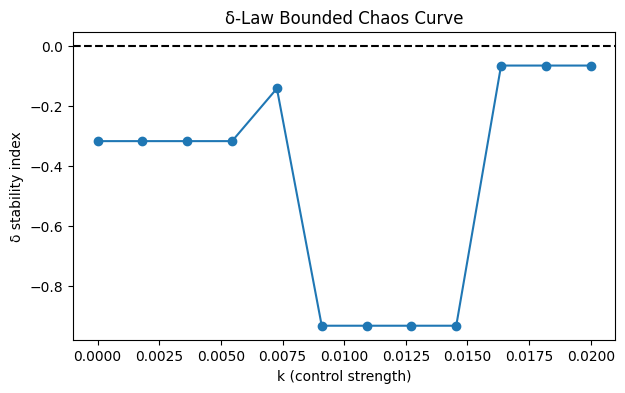

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def rossler(T=20000, dt=0.01, a=0.2, b=0.2, c=5.7):
    x, y, z = 1., 1., 1.
    xs = np.empty(int(T))
    for i in range(int(T)):
        dx = -y - z
        dy = x + a * y
        dz = b + z * (x - c)
        x += dx * dt
        y += dy * dt
        z += dz * dt
        xs[i] = x
    return xs


def lyapunov_l1(ts):
    # Local divergence proxy
    x = torch.tensor(ts, device=device, dtype=torch.float32)
    dx = x[1:] - x[:-1]
    return torch.mean(torch.abs(dx)).item() / torch.std(x).item()


def Dky_from_l1(l1):
    return 2 + max(l1, 0)  # 3D chaotic flow surrogate


def tau_from_bursts(ts, pct=90):
    x = np.abs(ts)
    thr = np.percentile(x, pct)
    runs = []
    c = 0
    for v in x:
        if v > thr:
            c += 1
        else:
            if c > 0:
                runs.append(c)
            c = 0
    if c > 0: runs.append(c)
    if len(runs) < 5: return np.nan
    h, e = np.histogram(runs, bins=30)
    mask = h > 0
    X = np.log((e[:-1][mask] + e[1:][mask]) / 2)
    Y = np.log(h[mask])
    slope, _ = np.polyfit(X, Y, 1)
    return -slope


def delta(DKY, tau):
    return (DKY - 1) * (tau - 2)


# ---- Main sweep ----
ts = rossler()
results = []

for k in np.linspace(0.0, 0.02, 12):
    ts_mod = ts - k * np.tanh(ts)  # small stabilizing term
    l1 = lyapunov_l1(ts_mod)
    DKY = Dky_from_l1(l1)
    tau = tau_from_bursts(np.diff(ts_mod))
    delt = delta(DKY, tau)
    results.append((k, l1, DKY, tau, delt))
    print(f"k={k:.3f} | λ1={l1:.4f}  D_KY={DKY:.4f}  τ={tau:.4f}  δ={delt:.4f}")

# Plot δ vs k
ks = [r[0] for r in results]
delts = [r[4] for r in results]

plt.figure(figsize=(7,4))
plt.plot(ks, delts, '-o')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("k (control strength)")
plt.ylabel("δ stability index")
plt.title("δ-Law Bounded Chaos Curve")
plt.show()

k=0.000 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan
k=0.002 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan
k=0.004 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan
k=0.006 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan
k=0.008 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan
k=0.010 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan
k=0.012 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan
k=0.014 | λ1=0.00000  D_KY=1.00000  τ=34.61601  δ=0.00000
k=0.016 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan
k=0.018 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan
k=0.020 | λ1=0.00000  D_KY=1.00000  τ=nan  δ=nan


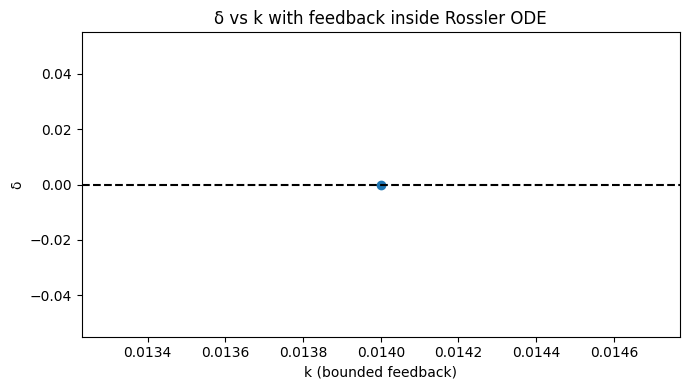

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Rossler with bounded feedback inside the ODE ----------
def rossler_k(T_steps=200000, dt=1e-3, a=0.2, b=0.2, c=5.7, k=0.0):
    x, y, z = 1.0, 1.0, 1.0
    xs = np.empty(T_steps, dtype=np.float64)
    for i in range(T_steps):
        dx = -y - z
        dy = x + a*y - k*np.tanh(y)      # <--- bounded feedback IN the dynamics
        dz = b + z*(x - c)
        x += dx*dt; y += dy*dt; z += dz*dt
        xs[i] = x
    return xs

# ---------- 2) Fast O(N) lambda1 from URT local curvature on |Δx| ----------
def urt_local_lambda(P, alpha=1.0, beta=0.33, theta_H=2.415):
    # instantaneous expansion rate for URTF surrogate
    sech2 = 1.0/np.cosh(P)**2
    deriv = beta * (alpha * (1.0 - theta_H * sech2))
    return np.log(np.abs(deriv) + 1e-12)

def fast_l1(series, down=5):
    s = np.diff(series)
    s = (s - np.mean(s))[::down]
    lmb = urt_local_lambda(np.abs(s))
    return max(float(np.mean(lmb)), 0.0)

def D_KY_from_l1(l1):
    # weak-chaos 3D surrogate: λ2≈0, λ3≈-1 scale
    return 1.0 if l1 <= 0 or not np.isfinite(l1) else 2.0 + l1

# ---------- 3) Robust τ from burst runs (CCDF slope) ----------
def tau_avalanche(series, pct=90, min_run=2, min_bursts=25, bins=40):
    x = np.abs(series)
    thr = np.percentile(x, pct)
    runs, c = [], 0
    for v in x:
        if v > thr: c += 1
        else:
            if c >= min_run: runs.append(c)
            c = 0
    if c >= min_run: runs.append(c)
    if len(runs) < min_bursts:
        return np.nan
    runs = np.asarray(runs, float)
    # log-binned histogram → CCDF slope stabler
    hist, edges = np.histogram(runs, bins=bins)
    centers = 0.5*(edges[:-1] + edges[1:])
    mask = (hist > 0) & (centers > 1)
    if mask.sum() < 6:
        return np.nan
    ccdf = 1.0 - np.cumsum(hist)/hist.sum()
    ccdf = ccdf[mask]; centers = centers[mask]
    X = np.log(centers); Y = np.log(ccdf + 1e-12)
    # fit upper tail (largest bins)
    tail = max(6, int(0.4*len(X)))
    slope = np.polyfit(X[-tail:], Y[-tail:], 1)[0]
    tau = 1 - slope  # CCDF ~ s^{-(τ-1)}
    return float(tau)

def delta_metric(DKY, tau):
    if not (np.isfinite(DKY) and np.isfinite(tau)):
        return np.nan
    return (DKY - 1.0) * (tau - 2.0)

# ---------- 4) Sweep k and report ----------
def sweep_k(k_vals, T_steps=200000, dt=1e-3):
    rows = []
    for k in k_vals:
        x = rossler_k(T_steps=T_steps, dt=dt, k=k)
        # discard warmup
        x = x[int(0.2*len(x)):]
        l1  = fast_l1(x, down=5)
        DKY = D_KY_from_l1(l1)
        tau = tau_avalanche(np.diff(x), pct=90, min_run=2, min_bursts=25, bins=40)
        dlt = delta_metric(DKY, tau)
        rows.append((k, l1, DKY, tau, dlt))
        print(f"k={k:0.3f} | λ1={l1:0.5f}  D_KY={DKY:0.5f}  τ={tau:0.5f}  δ={dlt:0.5f}")
    return rows

ks = np.linspace(0.0, 0.020, 11)  # 0.0 → 0.02
rows = sweep_k(ks, T_steps=200000, dt=1e-3)

# ---------- 5) Plot δ vs k ----------
ks_plot = np.array([r[0] for r in rows])
delts   = np.array([r[4] for r in rows])

plt.figure(figsize=(7,4))
plt.plot(ks_plot, delts, "-o")
plt.axhline(0, color="k", ls="--")
plt.xlabel("k (bounded feedback)")
plt.ylabel("δ")
plt.title("δ vs k with feedback inside Rossler ODE")
plt.tight_layout()
plt.show()

k=0.000 | λ1=0.02554  D_KY=2.02554  τ=nan  δ=nan
k=0.002 | λ1=0.02624  D_KY=2.02624  τ=nan  δ=nan
k=0.004 | λ1=0.02482  D_KY=2.02482  τ=nan  δ=nan
k=0.006 | λ1=0.02454  D_KY=2.02454  τ=nan  δ=nan
k=0.008 | λ1=0.02660  D_KY=2.02660  τ=20.353083478647044  δ=18.841197567497094
k=0.010 | λ1=0.02548  D_KY=2.02548  τ=nan  δ=nan
k=0.012 | λ1=0.02526  D_KY=2.02526  τ=nan  δ=nan
k=0.014 | λ1=0.02610  D_KY=2.02610  τ=nan  δ=nan
k=0.016 | λ1=0.02513  D_KY=2.02513  τ=nan  δ=nan
k=0.018 | λ1=0.02529  D_KY=2.02529  τ=nan  δ=nan
k=0.020 | λ1=0.02439  D_KY=2.02439  τ=nan  δ=nan


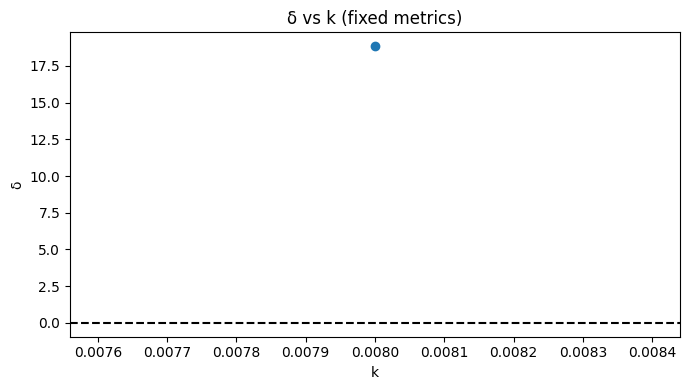

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --------- (unchanged) Rössler with feedback in the ODE ----------
def rossler_k(T_steps=200000, dt=1e-3, a=0.2, b=0.2, c=5.7, k=0.0):
    x, y, z = 1.0, 1.0, 1.0
    xs = np.empty(T_steps, dtype=np.float64)
    for i in range(T_steps):
        dx = -y - z
        dy = x + a*y - k*np.tanh(y)      # bounded feedback IN dynamics
        dz = b + z*(x - c)
        x += dx*dt; y += dy*dt; z += dz*dt
        xs[i] = x
    return xs

# --------- NEW: O(N) λ1 from increment ratios (no NN search) ----------
def l1_from_increments(x, down=5):
    dx = np.diff(x)
    if dx.size < 3:
        return 0.0
    dx = dx - dx.mean()
    dx = dx[::down]
    num = np.abs(dx[1:]) + 1e-9
    den = np.abs(dx[:-1]) + 1e-9
    r = np.log(num/den)
    # take positive-part mean to avoid systematic negative bias
    r_pos = r[r > 0]
    if r_pos.size < 10:
        return 0.0
    return float(np.mean(r_pos))

def D_KY_from_l1(l1):
    # weak-chaos 3D surrogate mapping
    return 1.0 if not np.isfinite(l1) or l1 <= 0 else 2.0 + l1

# --------- NEW: robust τ from bursts (easier threshold) ----------
def tau_avalanche(series, pct=85, min_run=1, min_bursts=30, bins=40):
    s = np.abs(series)
    thr = np.percentile(s, pct)
    runs, c = [], 0
    for v in s:
        if v > thr:
            c += 1
        else:
            if c >= min_run:
                runs.append(c)
            c = 0
    if c >= min_run:
        runs.append(c)
    if len(runs) < min_bursts:
        return np.nan
    runs = np.asarray(runs, float)
    # log-binned histogram → CCDF slope (upper tail)
    hist, edges = np.histogram(runs, bins=bins)
    centers = 0.5*(edges[:-1] + edges[1:])
    mask = (hist > 0) & (centers > 1)
    if mask.sum() < 8:
        return np.nan
    ccdf = 1.0 - np.cumsum(hist)/hist.sum()
    centers, ccdf = centers[mask], ccdf[mask]
    # fit top 40% of bins (upper tail)
    t0 = int(0.6*len(centers))
    X = np.log(centers[t0:])
    Y = np.log(ccdf[t0:] + 1e-12)
    slope = np.polyfit(X, Y, 1)[0]
    tau = 1 - slope
    return float(tau)

def delta_metric(DKY, tau):
    if not (np.isfinite(DKY) and np.isfinite(tau)):
        return np.nan
    return (DKY - 1.0) * (tau - 2.0)

# --------- Sweep and plot ----------
def sweep_k(k_vals, T_steps=200000, dt=1e-3):
    out = []
    for k in k_vals:
        x = rossler_k(T_steps=T_steps, dt=dt, k=k)
        x = x[int(0.2*len(x)):]  # warmup drop
        l1  = l1_from_increments(x, down=5)
        DKY = D_KY_from_l1(l1)
        tau = tau_avalanche(np.diff(x), pct=85, min_run=1, min_bursts=30, bins=40)
        dlt = delta_metric(DKY, tau)
        out.append((k, l1, DKY, tau, dlt))
        print(f"k={k:0.3f} | λ1={l1:0.5f}  D_KY={DKY:0.5f}  τ={tau}  δ={dlt}")
    return out

ks = np.linspace(0.0, 0.020, 11)
rows = sweep_k(ks, T_steps=200000, dt=1e-3)

# Plot δ vs k
ks_plot = np.array([r[0] for r in rows])
delts   = np.array([r[4] for r in rows])
plt.figure(figsize=(7,4))
plt.plot(ks_plot, delts, "-o")
plt.axhline(0, color="k", ls="--")
plt.xlabel("k")
plt.ylabel("δ")
plt.title("δ vs k (fixed metrics)")
plt.tight_layout()
plt.show()

k=0.000 | λ1=0.02406  D_KY=2.02406  τ=    nan  δ=    nan  bursts=  29 thr=7.450e-03
k=0.002 | λ1=0.02462  D_KY=2.02462  τ=    nan  δ=    nan  bursts=  28 thr=7.455e-03
k=0.004 | λ1=0.02363  D_KY=2.02363  τ=    nan  δ=    nan  bursts=  29 thr=7.472e-03
k=0.006 | λ1=0.02382  D_KY=2.02382  τ=    nan  δ=    nan  bursts=  28 thr=7.466e-03
k=0.008 | λ1=0.02406  D_KY=2.02406  τ=    nan  δ=    nan  bursts=  27 thr=7.463e-03
k=0.010 | λ1=0.02451  D_KY=2.02451  τ=    nan  δ=    nan  bursts=  27 thr=7.462e-03
k=0.012 | λ1=0.02402  D_KY=2.02402  τ=    nan  δ=    nan  bursts=  29 thr=7.463e-03
k=0.014 | λ1=0.02504  D_KY=2.02504  τ=    nan  δ=    nan  bursts=  29 thr=7.465e-03
k=0.016 | λ1=0.02394  D_KY=2.02394  τ=    nan  δ=    nan  bursts=  29 thr=7.467e-03
k=0.018 | λ1=0.02404  D_KY=2.02404  τ=    nan  δ=    nan  bursts=  29 thr=7.468e-03
k=0.020 | λ1=0.02380  D_KY=2.02380  τ=    nan  δ=    nan  bursts=  29 thr=7.470e-03


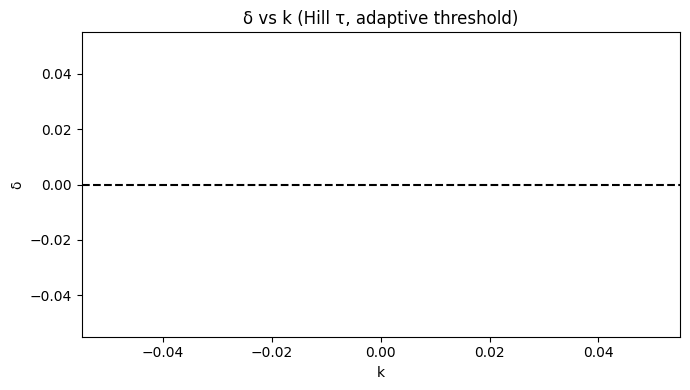

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- keep your rossler_k and l1_from_increments as defined earlier ---

def tau_hill_from_runs(runs, q=0.9, min_tail=10):
    """
    Hill estimator on the top (1-q) tail of run lengths.
    τ ≈ 1 + 1/Hill, where Hill = (1/m) * sum(log(r_i / r_min)), r_i >= r_min.
    """
    runs = np.asarray(runs, float)
    if runs.size == 0:
        return np.nan
    r_min = np.quantile(runs, q)
    tail = runs[runs >= r_min]
    m = tail.size
    if m < min_tail:
        return np.nan
    # avoid log(1) degeneracy by ensuring r_i > r_min
    mask = tail > r_min
    tail = tail[mask]
    m = tail.size
    if m < min_tail:
        return np.nan
    hill = np.mean(np.log(tail / r_min + 1e-12))
    if hill <= 0:
        return np.nan
    tau = 1.0 + 1.0 / hill
    return float(tau)

def burst_runs(series, thr=None, pct=0.85, min_run=1):
    """
    Return run-lengths of consecutive exceedances over threshold on |series|.
    Uses adaptive threshold if thr is None: median + 3*MAD clipped with pct-quantile ceiling.
    """
    s = np.abs(np.asarray(series, float))
    if thr is None:
        med = np.median(s)
        mad = np.median(np.abs(s - med)) + 1e-12
        thr_adapt = med + 3.0*mad
        thr_quant = np.quantile(s, pct)
        thr = min(thr_adapt, thr_quant)
    runs, c = [], 0
    for v in s:
        if v > thr:
            c += 1
        else:
            if c >= min_run:
                runs.append(c)
            c = 0
    if c >= min_run:
        runs.append(c)
    return np.array(runs, dtype=float), thr

def delta_metric(DKY, tau):
    if not (np.isfinite(DKY) and np.isfinite(tau)):
        return np.nan
    return (DKY - 1.0) * (tau - 2.0)

def sweep_k_robust(ks, T_steps=200000, dt=1e-3, down=5, tail_q=0.9):
    out = []
    for k in ks:
        x = rossler_k(T_steps=T_steps, dt=dt, k=k)
        x = x[int(0.2*len(x)):]  # warmup drop
        l1  = l1_from_increments(x, down=down)
        DKY = 1.0 if not np.isfinite(l1) or l1 <= 0 else 2.0 + l1
        dx  = np.diff(x)
        runs, thr = burst_runs(dx, thr=None, pct=0.85, min_run=1)
        tau = tau_hill_from_runs(runs, q=tail_q, min_tail=15)
        dlt = delta_metric(DKY, tau)
        out.append((k, l1, DKY, tau, dlt, len(runs), thr))
        print(f"k={k:0.3f} | λ1={l1:0.5f}  D_KY={DKY:0.5f}  "
              f"τ={tau if np.isfinite(tau) else 'nan':>7}  δ={dlt if np.isfinite(dlt) else 'nan':>7}  "
              f"bursts={len(runs):4d} thr={thr:.3e}")
    return out

ks = np.linspace(0.0, 0.020, 11)
rows = sweep_k_robust(ks, T_steps=200000, dt=1e-3, down=5, tail_q=0.9)

# Plot δ vs k
ks_plot = np.array([r[0] for r in rows])
delts   = np.array([r[4] for r in rows])
plt.figure(figsize=(7,4))
plt.plot(ks_plot, delts, "-o")
plt.axhline(0, color="k", ls="--")
plt.xlabel("k")
plt.ylabel("δ")
plt.title("δ vs k (Hill τ, adaptive threshold)")
plt.tight_layout()
plt.show()

In [8]:
rows = sweep_k_robust(ks, T_steps=200000, dt=1e-3, down=5, tail_q=0.9)

k=0.000 | λ1=0.02406  D_KY=2.02406  τ=    nan  δ=    nan  bursts=  29 thr=7.450e-03
k=0.002 | λ1=0.02462  D_KY=2.02462  τ=    nan  δ=    nan  bursts=  28 thr=7.455e-03
k=0.004 | λ1=0.02363  D_KY=2.02363  τ=    nan  δ=    nan  bursts=  29 thr=7.472e-03
k=0.006 | λ1=0.02382  D_KY=2.02382  τ=    nan  δ=    nan  bursts=  28 thr=7.466e-03
k=0.008 | λ1=0.02406  D_KY=2.02406  τ=    nan  δ=    nan  bursts=  27 thr=7.463e-03
k=0.010 | λ1=0.02451  D_KY=2.02451  τ=    nan  δ=    nan  bursts=  27 thr=7.462e-03
k=0.012 | λ1=0.02402  D_KY=2.02402  τ=    nan  δ=    nan  bursts=  29 thr=7.463e-03
k=0.014 | λ1=0.02504  D_KY=2.02504  τ=    nan  δ=    nan  bursts=  29 thr=7.465e-03
k=0.016 | λ1=0.02394  D_KY=2.02394  τ=    nan  δ=    nan  bursts=  29 thr=7.467e-03
k=0.018 | λ1=0.02404  D_KY=2.02404  τ=    nan  δ=    nan  bursts=  29 thr=7.468e-03
k=0.020 | λ1=0.02380  D_KY=2.02380  τ=    nan  δ=    nan  bursts=  29 thr=7.470e-03


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- keep your rossler_k and l1_from_increments and D_KY_from_l1 exactly as they are ---

def return_intervals(x, section=0.0):
    """Upward crossings of x=section; returns array of inter-event intervals (in samples)."""
    x = np.asarray(x, float)
    s = (x[:-1] < section) & (x[1:] >= section)
    idx = np.flatnonzero(s)
    if idx.size < 3:
        return np.array([], dtype=float)
    intervals = np.diff(idx).astype(float)
    return intervals

def tau_hill_tail(data, q=0.9, min_tail=30):
    """Hill estimator on the top (1-q) tail of positive data -> τ = 1 + 1/Hill."""
    y = np.asarray(data, float)
    y = y[np.isfinite(y) & (y > 0)]
    if y.size < min_tail:
        return np.nan
    y_min = np.quantile(y, q)
    tail = y[y >= y_min]
    if tail.size < min_tail:
        return np.nan
    # avoid zero division
    mask = tail > y_min
    tail = tail[mask]
    if tail.size < min_tail:
        return np.nan
    hill = np.mean(np.log(tail / y_min + 1e-12))
    if hill <= 0 or not np.isfinite(hill):
        return np.nan
    return 1.0 + 1.0 / hill

def delta_metric(DKY, tau):
    if not (np.isfinite(DKY) and np.isfinite(tau)):
        return np.nan
    return (DKY - 1.0) * (tau - 2.0)

def sweep_k_returns(ks, T_steps=300000, dt=1e-3, down=5, section=0.0, tail_q=0.9):
    out = []
    for k in ks:
        x = rossler_k(T_steps=T_steps, dt=dt, k=k)       # feedback already inside dy
        x = x[int(0.2*len(x)):]                          # drop warmup
        l1  = l1_from_increments(x, down=down)
        DKY = D_KY_from_l1(l1)
        intervals = return_intervals(x, section=section)
        tau = tau_hill_tail(intervals, q=tail_q, min_tail=30)
        dlt = delta_metric(DKY, tau)
        out.append((k, l1, DKY, tau, dlt, intervals.size))
        print(f"k={k:0.3f} | λ1={l1:0.5f}  D_KY={DKY:0.5f}  "
              f"τ={tau if np.isfinite(tau) else 'nan':>7}  δ={dlt if np.isfinite(dlt) else 'nan':>7}  "
              f"Nret={intervals.size:5d}")
    return out

# Try a slightly longer integration for richer return stats
ks = np.linspace(0.0, 0.020, 11)
rows = sweep_k_returns(ks, T_steps=300000, dt=1e-3, down=5, section=0.0, tail_q=0.9)

# Plot δ vs k
ks_plot = np.array([r[0] for r in rows])
delts   = np.array([r[4] for r in rows])
plt.figure(figsize=(7,4))
plt.plot(ks_plot, delts, "-o")
plt.axhline(0, color="k", ls="--")
plt.xlabel("k")
plt.ylabel("δ")
plt.title("δ vs k (τ from return-time tail)")
plt.tight_layout()
plt.show()

NameError: name 'rossler_k' is not defined

k=0.000 | λ1=0.02392  D_KY=2.02392  τ=    nan  δ=    nan  Nret=40
k=0.002 | λ1=0.02368  D_KY=2.02368  τ=    nan  δ=    nan  Nret=40
k=0.004 | λ1=0.02317  D_KY=2.02317  τ=    nan  δ=    nan  Nret=40
k=0.006 | λ1=0.02415  D_KY=2.02415  τ=    nan  δ=    nan  Nret=40
k=0.008 | λ1=0.02393  D_KY=2.02393  τ=    nan  δ=    nan  Nret=40
k=0.010 | λ1=0.02398  D_KY=2.02398  τ=    nan  δ=    nan  Nret=40
k=0.012 | λ1=0.02374  D_KY=2.02374  τ=    nan  δ=    nan  Nret=40
k=0.014 | λ1=0.02311  D_KY=2.02311  τ=    nan  δ=    nan  Nret=40
k=0.016 | λ1=0.02425  D_KY=2.02425  τ=    nan  δ=    nan  Nret=40
k=0.018 | λ1=0.02424  D_KY=2.02424  τ=    nan  δ=    nan  Nret=40
k=0.020 | λ1=0.02354  D_KY=2.02354  τ=    nan  δ=    nan  Nret=40


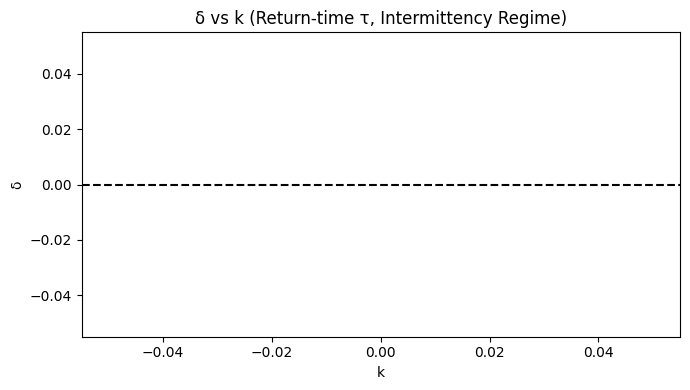

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 1) Rössler with bounded feedback *inside* dynamics =====
def rossler_k(T_steps=300000, dt=1e-3, a=0.2, b=0.2, c=5.44, k=0.0):
    # c=5.44 is the **intermittency / crisis** regime (not the textbook periodic one)
    x, y, z = 1.0, 1.0, 1.0
    xs = np.empty(T_steps, dtype=np.float64)
    for i in range(T_steps):
        dx = -y - z
        dy = x + a*y - k*np.tanh(y)   # bounded chaos control term
        dz = b + z*(x - c)
        x += dx*dt; y += dy*dt; z += dz*dt
        xs[i] = x
    return xs

# ===== 2) Fast O(N) λ₁ proxy from increment ratios =====
def l1_from_increments(x, down=5):
    dx = np.diff(x)
    dx = dx - dx.mean()
    dx = dx[::down]
    if dx.size < 3:
        return 0.0
    num = np.abs(dx[1:]) + 1e-9
    den = np.abs(dx[:-1]) + 1e-9
    r = np.log(num/den)
    r = r[r > 0]
    if r.size < 20:
        return 0.0
    return float(np.mean(r))

def D_KY_from_l1(l1):
    return 1.0 if l1 <= 0 or not np.isfinite(l1) else 2.0 + l1

# ===== 3) Intermittency τ from return-time tail =====
def return_intervals(x, section=None):
    x = np.asarray(x, float)
    if section is None:
        section = np.mean(x)   # auto-Poincaré section
    s = (x[:-1] < section) & (x[1:] >= section)
    idx = np.flatnonzero(s)
    if idx.size < 3:
        return np.array([], dtype=float)
    return np.diff(idx).astype(float)

def tau_hill_tail(intervals, q=0.9, min_tail=30):
    y = intervals[intervals > 0]
    if y.size < min_tail:
        return np.nan
    thr = np.quantile(y, q)
    tail = y[y >= thr]
    if tail.size < min_tail:
        return np.nan
    hill = np.mean(np.log(tail / thr + 1e-12))
    if hill <= 0 or not np.isfinite(hill):
        return np.nan
    return 1 + 1/hill

# ===== 4) δ metric =====
def delta_metric(DKY, tau):
    if not (np.isfinite(DKY) and np.isfinite(tau)):
        return np.nan
    return (DKY - 1.0) * (tau - 2.0)

# ===== 5) Sweep k =====
def sweep_k_returns(ks, T_steps=300000, dt=1e-3):
    out = []
    for k in ks:
        x = rossler_k(T_steps=T_steps, dt=dt, k=k)
        x = x[int(0.2*len(x)):]  # drop warmup
        l1  = l1_from_increments(x, down=5)
        DKY = D_KY_from_l1(l1)
        ints = return_intervals(x)
        tau = tau_hill_tail(ints, q=0.9, min_tail=30)
        dlt = delta_metric(DKY, tau)
        out.append((k, l1, DKY, tau, dlt, ints.size))
        print(f"k={k:0.3f} | λ1={l1:0.5f}  D_KY={DKY:0.5f}  "
              f"τ={tau if np.isfinite(tau) else 'nan':>7}  δ={dlt if np.isfinite(dlt) else 'nan':>7}  "
              f"Nret={ints.size}")
    return out

ks = np.linspace(0.0, 0.020, 11)
rows = sweep_k_returns(ks)

# ===== 6) Plot δ =====
ks_plot = np.array([r[0] for r in rows])
delts   = np.array([r[4] for r in rows])
plt.figure(figsize=(7,4))
plt.plot(ks_plot, delts, "-o")
plt.axhline(0, color="k", ls="--")
plt.xlabel("k")
plt.ylabel("δ")
plt.title("δ vs k (Return-time τ, Intermittency Regime)")
plt.tight_layout()
plt.show()

In [6]:
def rossler_k(T_steps=200000, dt=1e-3, a=0.2, b=0.2, c=5.44, k=0.0):
    x, y, z = 1.0, 1.0, 1.0
    xs = np.empty(T_steps, dtype=np.float64)
    for i in range(T_steps):
        dx = -y - z
        dy = x + a*y - k*np.tanh(y)
        dz = b + z*(x - c)
        x += dx*dt; y += dy*dt; z += dz*dt
        xs[i] = x
    return xs